In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.chdir('/content/drive/MyDrive/credit-risk-assessment-system')

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_recall_curve

X_train = pd.read_csv('data/processed/X_train_fe.csv')
X_test = pd.read_csv('data/processed/X_test_fe.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()

leftover_cols = [c for c in ['SK_ID_CURR', 'AMT_ANNUITY_RAW', 'AMT_CREDIT_RAW', 'AMT_INCOME_TOTAL_RAW']
                  if c in X_train.columns]
X_train_model = X_train.drop(columns=leftover_cols)
X_test_model = X_test.drop(columns=leftover_cols)

print(X_train_model.shape, X_test_model.shape)

(246008, 191) (61503, 191)


In [3]:
!pip install catboost -q

In [4]:
import joblib
final_catboost = joblib.load('models/catboost_tuned_final.pkl')
print("Model loaded")

Model loaded


In [5]:
y_pred_default = final_catboost.predict(X_test_model)
print("Default threshold (0.5) - Tuned CatBoost:")
print(classification_report(y_test, y_pred_default))

Default threshold (0.5) - Tuned CatBoost:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.60      0.02      0.03      4965

    accuracy                           0.92     61503
   macro avg       0.76      0.51      0.50     61503
weighted avg       0.89      0.92      0.88     61503



In [6]:
from catboost import CatBoostClassifier

best_params = {
    'iterations': 477,
    'depth': 7,
    'learning_rate': 0.042106168367021204,
    'l2_leaf_reg': 7.2626141545771805,
    'random_state': 42,
    'verbose': 0
}

catboost_weighted = CatBoostClassifier(**best_params, auto_class_weights='Balanced')
catboost_weighted.fit(X_train_model, y_train)

y_pred_weighted = catboost_weighted.predict(X_test_model)
y_pred_proba_weighted = catboost_weighted.predict_proba(X_test_model)[:, 1]

print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba_weighted))
print(classification_report(y_test, y_pred_weighted))

AUC-ROC: 0.7634639654702733
              precision    recall  f1-score   support

           0       0.96      0.72      0.82     56538
           1       0.17      0.68      0.28      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.70      0.55     61503
weighted avg       0.90      0.71      0.78     61503



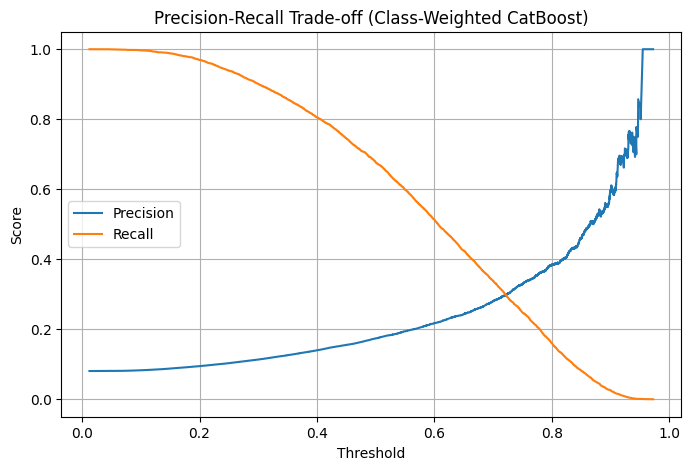

In [7]:
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_weighted)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off (Class-Weighted CatBoost)')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
diffs = np.abs(precisions[:-1] - recalls[:-1])
optimal_idx = np.argmin(diffs)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"Precision at this point: {precisions[optimal_idx]:.4f}")
print(f"Recall at this point: {recalls[optimal_idx]:.4f}")

Optimal threshold: 0.7215
Precision at this point: 0.2977
Recall at this point: 0.2977


In [9]:
y_pred_optimal = (y_pred_proba_weighted >= optimal_threshold).astype(int)

print(f"\nClassification report at threshold = {optimal_threshold:.4f}:")
print(classification_report(y_test, y_pred_optimal))
print(confusion_matrix(y_test, y_pred_optimal))


Classification report at threshold = 0.7215:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     56538
           1       0.30      0.30      0.30      4965

    accuracy                           0.89     61503
   macro avg       0.62      0.62      0.62     61503
weighted avg       0.89      0.89      0.89     61503

[[53051  3487]
 [ 3487  1478]]


In [10]:
import joblib

joblib.dump(catboost_weighted, 'models/catboost_weighted_final.pkl')

decision_config = {
    'optimal_threshold': float(optimal_threshold),
    'precision_at_threshold': float(precisions[optimal_idx]),
    'recall_at_threshold': float(recalls[optimal_idx])
}

import json
with open('models/decision_threshold.json', 'w') as f:
    json.dump(decision_config, f)

print("Saved weighted model and threshold config")

Saved weighted model and threshold config
